# Stock Price Forecasting — Facebook Prophet

**Model:** Facebook Prophet  
**Dữ liệu:** 5 mã VCB, FPT, HPG, VIC, VNM — Close Price  
**Chỉ số đánh giá:** RMSE, MAE, MAPE, R², Directional Accuracy

Notebook này giữ cấu trúc của `00_template.ipynb` và thay phần TODO bằng pipeline Prophet một biến, train riêng cho từng mã và từng split.


---
## Section 0 — Setup chung

In [13]:
import sys
print(sys.executable)
# Phải là: .../stock-time-series-main/.venv/bin/python


/Users/hobaoan/Desktop/stock-time-series-main/.venv/bin/python


In [14]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120})


In [15]:
# ── Cấu hình đường dẫn ──
ROOT        = Path('..').resolve()
SPLITS_DIR  = ROOT / 'data' / 'processed' / 'splits'
FEATURED_DIR = ROOT / 'data' / 'processed' / 'featured'

TICKERS = ['VCB', 'FPT', 'HPG', 'VIC', 'VNM']
SPLITS  = ['70_30', '80_20']

MODEL_NAME = 'Facebook Prophet'

RESULTS_DIR = ROOT / 'results' / MODEL_NAME.lower().replace(' ', '_')
PLOTS_DIR   = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('SPLITS_DIR:', SPLITS_DIR)
print('MODEL:', MODEL_NAME)


ROOT: /Users/hobaoan/Desktop/stock-time-series-main
SPLITS_DIR: /Users/hobaoan/Desktop/stock-time-series-main/data/processed/splits
MODEL: Facebook Prophet


---
## Section 1 — Hàm tiện ích (dùng chung, không sửa)

In [16]:
def load_split(ticker: str, split: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load train/test DataFrames cho một mã và một tỷ lệ split."""
    base = SPLITS_DIR / split
    train = pd.read_csv(base / f'{ticker}_train.csv', parse_dates=['date'])
    test  = pd.read_csv(base / f'{ticker}_test.csv',  parse_dates=['date'])
    return train.sort_values('date').reset_index(drop=True), \
           test.sort_values('date').reset_index(drop=True)

In [17]:
# ── compute_metrics — single source of truth tại src/metrics.py ──
# Trả về dict gồm: RMSE, MAE, MAPE (%), R²
# Truyền `prev_close` (giá đóng cửa của ngày liền trước) để có thêm "Directional Accuracy (%)".
import sys as _sys
_sys.path.insert(0, str(ROOT))
from src.metrics import compute_metrics  # noqa: E402


In [18]:
def plot_predictions(
    dates,
    y_true,
    y_pred,
    ticker: str,
    split: str,
    model_name: str,
    metrics: dict,
    save: bool = True,
) -> None:
    """Vẽ biểu đồ Actual vs Predicted và lưu file PNG."""
    fig, ax = plt.subplots(figsize=(14, 4.5))

    ax.plot(dates, y_true, label='Actual',    color='#2563EB', linewidth=1.2, alpha=0.85)
    ax.plot(dates, y_pred, label='Predicted', color='#DC2626', linewidth=1.2, alpha=0.85, linestyle='--')

    ratio_label = split.replace('_', '/')
    subtitle = (f"RMSE={metrics['RMSE']:,.2f}  "
                f"MAE={metrics['MAE']:,.2f}  "
                f"MAPE={metrics['MAPE (%)']:.2f}%  "
                f"R²={metrics['R²']:.4f}")
    ax.set_title(f"{model_name} — {ticker}  (Split {ratio_label})\n{subtitle}", pad=10)
    ax.set_xlabel('Ngày')
    ax.set_ylabel('Giá đóng cửa (VND × nghìn)')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=35, ha='right')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()

    if save:
        fname = PLOTS_DIR / f"{ticker}_{split}_{model_name.lower().replace(' ', '_')}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

In [19]:
def build_results_table(all_results: list[dict]) -> pd.DataFrame:
    """Tạo bảng tổng hợp RMSE/MAE/MAPE/R² (+ Directional Accuracy nếu có) cho tất cả mã và splits."""
    df = pd.DataFrame(all_results)
    cols = ['Ticker', 'Split', 'Model', 'RMSE', 'MAE', 'MAPE (%)', 'R²']
    if 'Directional Accuracy (%)' in df.columns:
        cols.append('Directional Accuracy (%)')
    df = df[cols].sort_values(['Split', 'Ticker']).reset_index(drop=True)
    df[['RMSE', 'MAE']] = df[['RMSE', 'MAE']].round(2)
    df['MAPE (%)'] = df['MAPE (%)'].round(3)
    df['R²'] = df['R²'].round(4)
    if 'Directional Accuracy (%)' in df.columns:
        df['Directional Accuracy (%)'] = df['Directional Accuracy (%)'].round(2)
    return df


---
## Section 2 — Feature Engineering

Prophet yêu cầu input gồm `ds` (ngày) và `y` (giá trị cần dự báo). Notebook chỉ dùng dữ liệu train để fit model, sau đó dự báo đúng các ngày giao dịch trong test set.


In [20]:
def prepare_data(train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Chuẩn bị dữ liệu theo schema Prophet: ds/y cho train và ds cho test."""
    prophet_train = (
        train_df[['date', 'close']]
        .rename(columns={'date': 'ds', 'close': 'y'})
        .dropna()
        .sort_values('ds')
        .reset_index(drop=True)
    )
    prophet_future = (
        test_df[['date']]
        .rename(columns={'date': 'ds'})
        .sort_values('ds')
        .reset_index(drop=True)
    )
    return prophet_train, prophet_future


---
## Section 3 — Huấn luyện & Dự báo *(TODO)*

Điền logic train và predict của model vào hàm `train_and_predict`.

In [21]:
def train_and_predict(train_df: pd.DataFrame, test_df: pd.DataFrame) -> np.ndarray:
    """Train Prophet trên train_df và dự báo close cho đúng các ngày trong test_df."""
    prophet_train, prophet_future = prepare_data(train_df, test_df)

    model = Prophet(
        growth='linear',
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05,
        interval_width=0.95,
    )

    try:
        model.add_country_holidays(country_name='VN')
    except Exception as exc:
        print(f'     Không thêm được holiday VN cho Prophet: {exc}')

    model.fit(prophet_train)
    forecast = model.predict(prophet_future)
    y_pred = forecast['yhat'].to_numpy(dtype=float)
    return np.clip(y_pred, a_min=0.0, a_max=None)


---
## Section 4 — Vòng lặp chính: Train → Evaluate → Plot

**Không cần sửa** — gọi `train_and_predict` và `compute_metrics` cho mọi (ticker, split).


  Split: 70/30

  > VCB...


22:22:01 - cmdstanpy - INFO - Chain [1] start processing
22:22:02 - cmdstanpy - INFO - Chain [1] done processing


     RMSE=13.62  MAE=13.17  MAPE=21.85%  R2=-11.1293  DA=51.0%


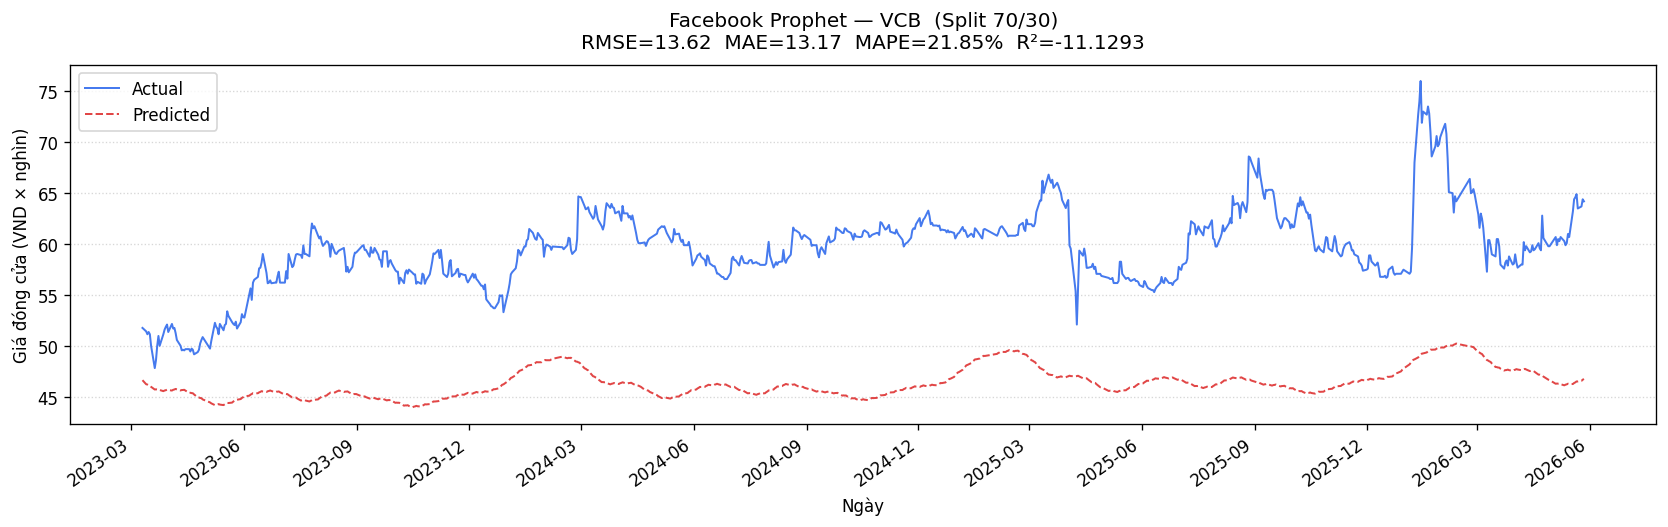


  > FPT...


22:22:02 - cmdstanpy - INFO - Chain [1] start processing
22:22:02 - cmdstanpy - INFO - Chain [1] done processing


     RMSE=43.09  MAE=37.27  MAPE=37.49%  R2=-2.6927  DA=49.8%


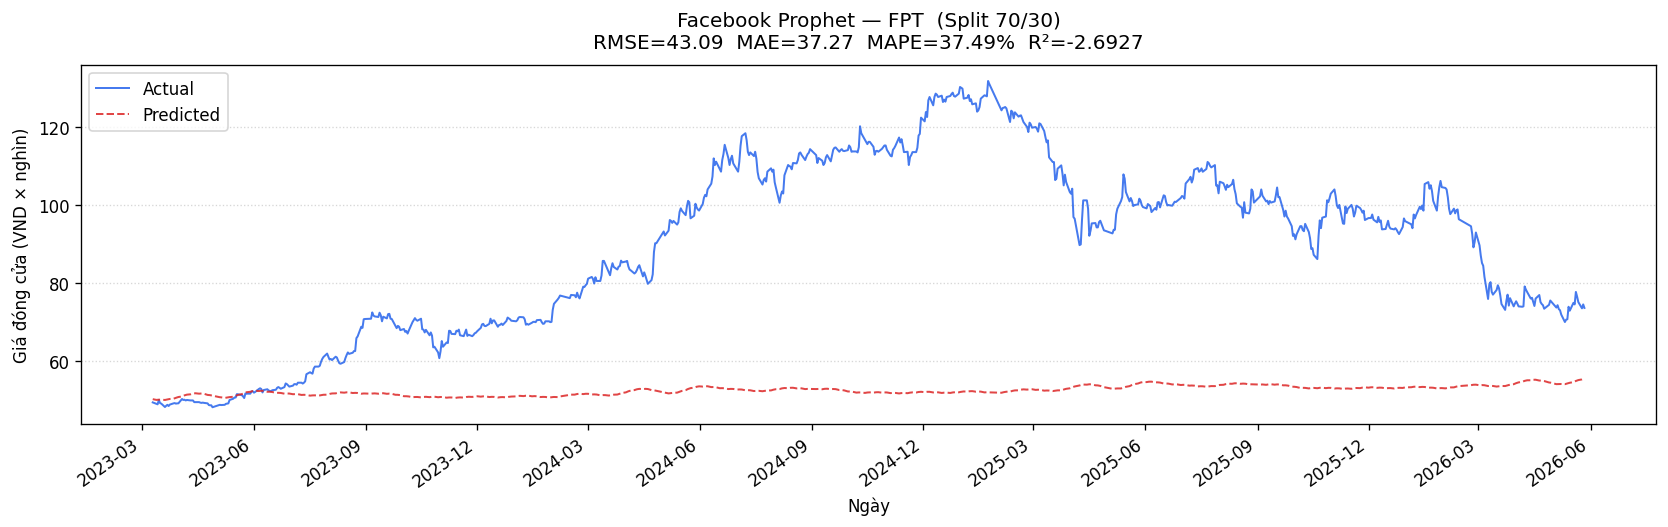


  > HPG...


22:22:03 - cmdstanpy - INFO - Chain [1] start processing
22:22:03 - cmdstanpy - INFO - Chain [1] done processing


     RMSE=19.75  MAE=19.06  MAPE=91.99%  R2=-42.0092  DA=50.8%


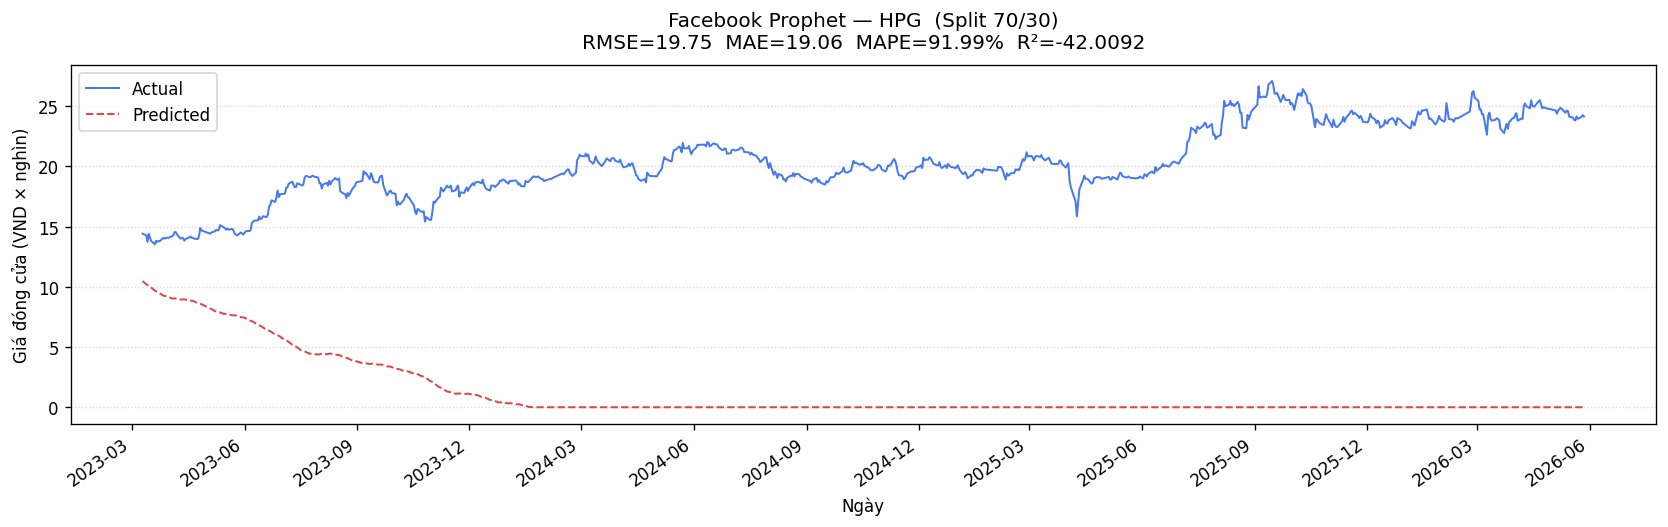


  > VIC...


22:22:04 - cmdstanpy - INFO - Chain [1] start processing
22:22:04 - cmdstanpy - INFO - Chain [1] done processing


     RMSE=73.12  MAE=46.85  MAPE=75.57%  R2=-0.9438  DA=47.1%


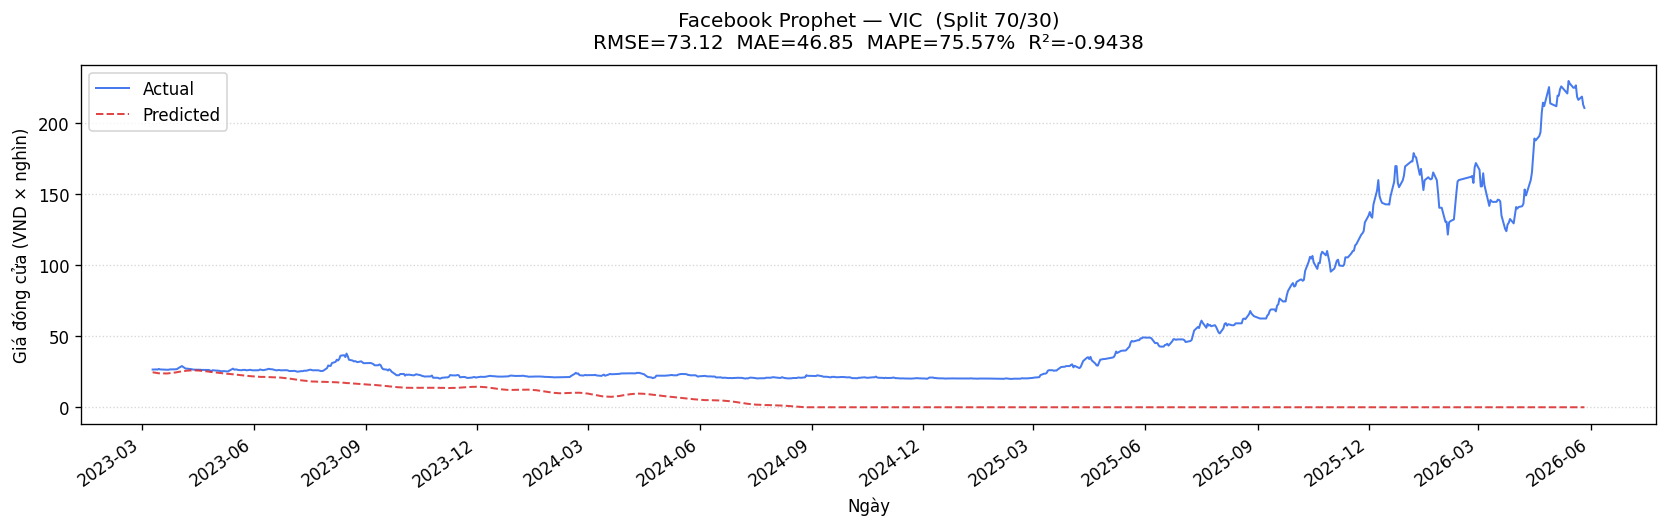


  > VNM...


22:22:04 - cmdstanpy - INFO - Chain [1] start processing
22:22:05 - cmdstanpy - INFO - Chain [1] done processing


     RMSE=9.03  MAE=7.42  MAPE=12.09%  R2=-4.4229  DA=54.2%


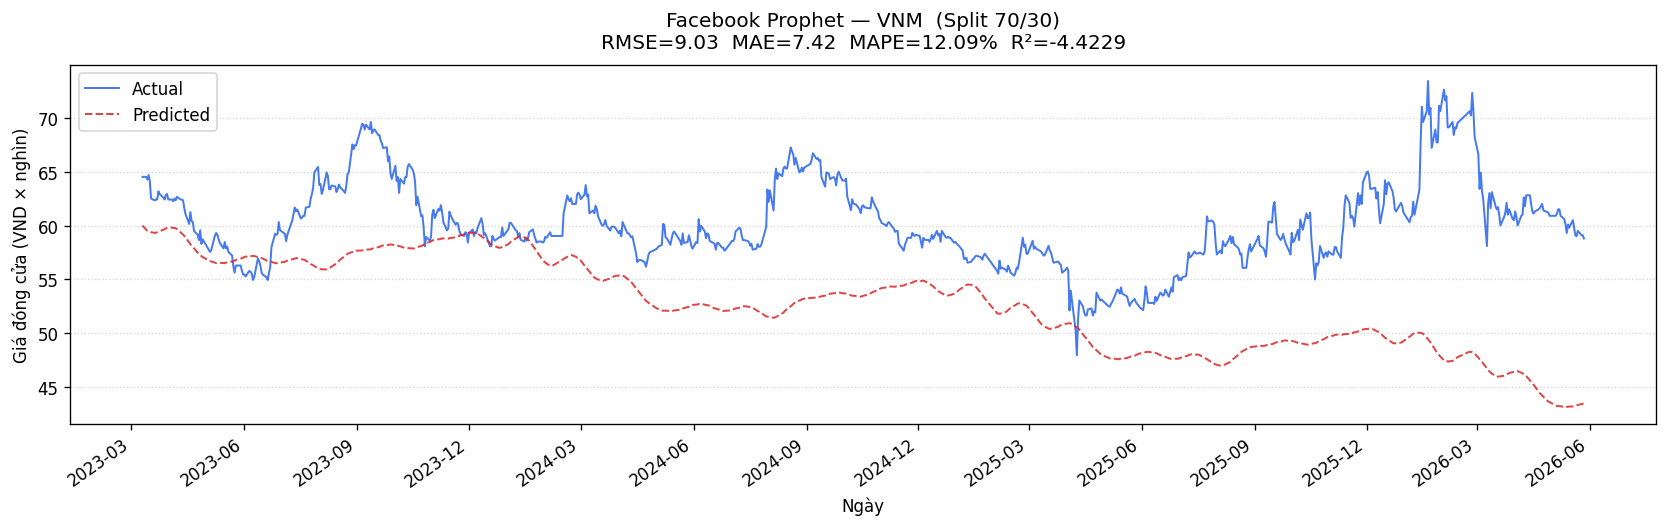


  Split: 80/20

  > VCB...


22:22:05 - cmdstanpy - INFO - Chain [1] start processing
22:22:06 - cmdstanpy - INFO - Chain [1] done processing


     RMSE=16.93  MAE=15.17  MAPE=25.18%  R2=-25.3718  DA=48.6%


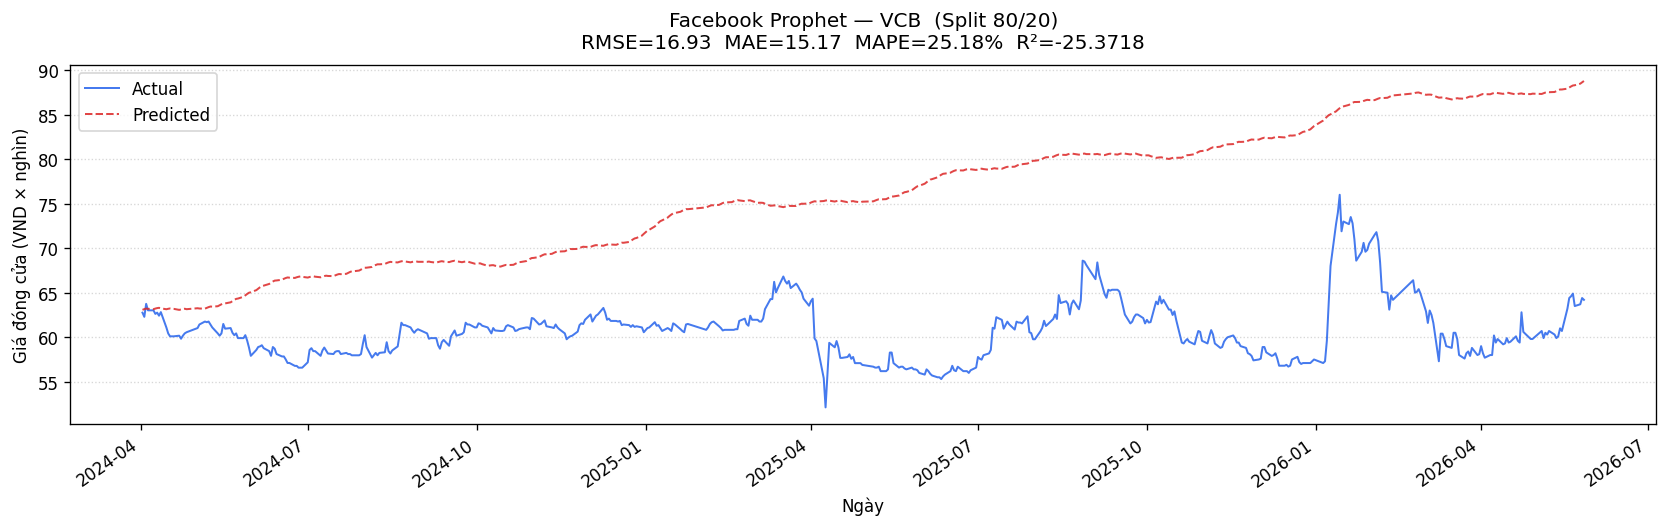


  > FPT...


22:22:06 - cmdstanpy - INFO - Chain [1] start processing
22:22:06 - cmdstanpy - INFO - Chain [1] done processing


     RMSE=24.39  MAE=20.18  MAPE=19.50%  R2=-2.0133  DA=48.2%


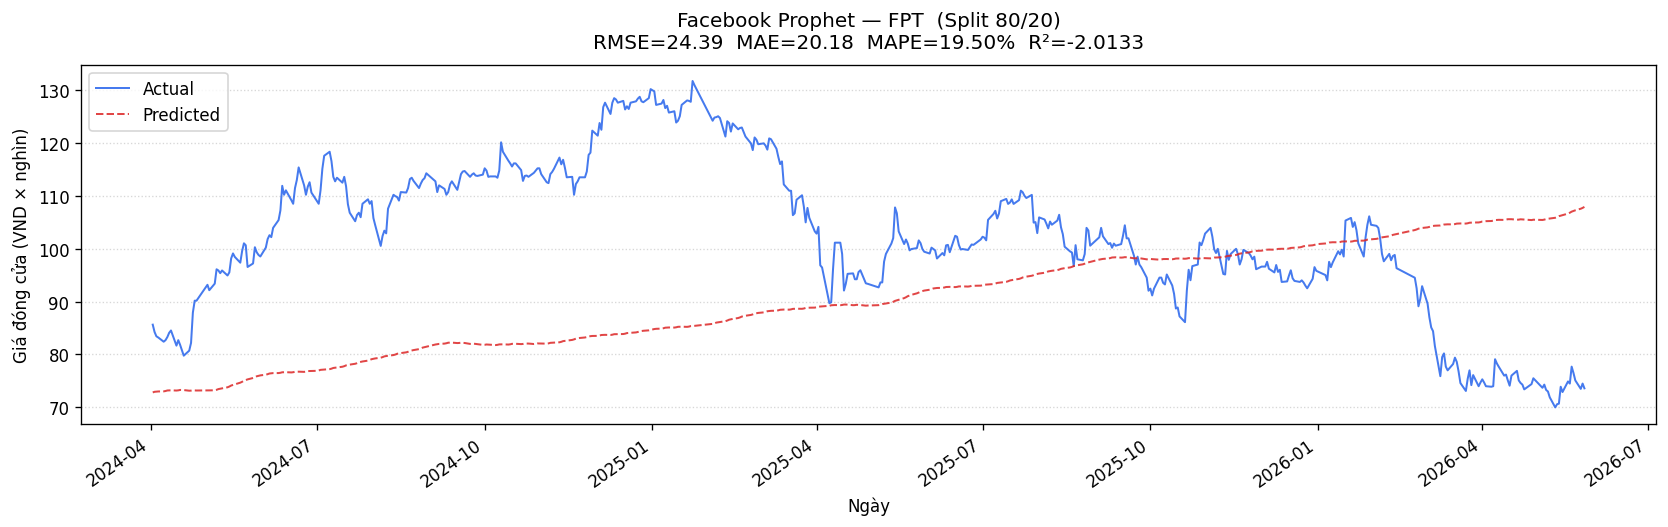


  > HPG...


22:22:07 - cmdstanpy - INFO - Chain [1] start processing
22:22:07 - cmdstanpy - INFO - Chain [1] done processing


     RMSE=2.48  MAE=2.08  MAPE=9.98%  R2=-0.1300  DA=49.4%


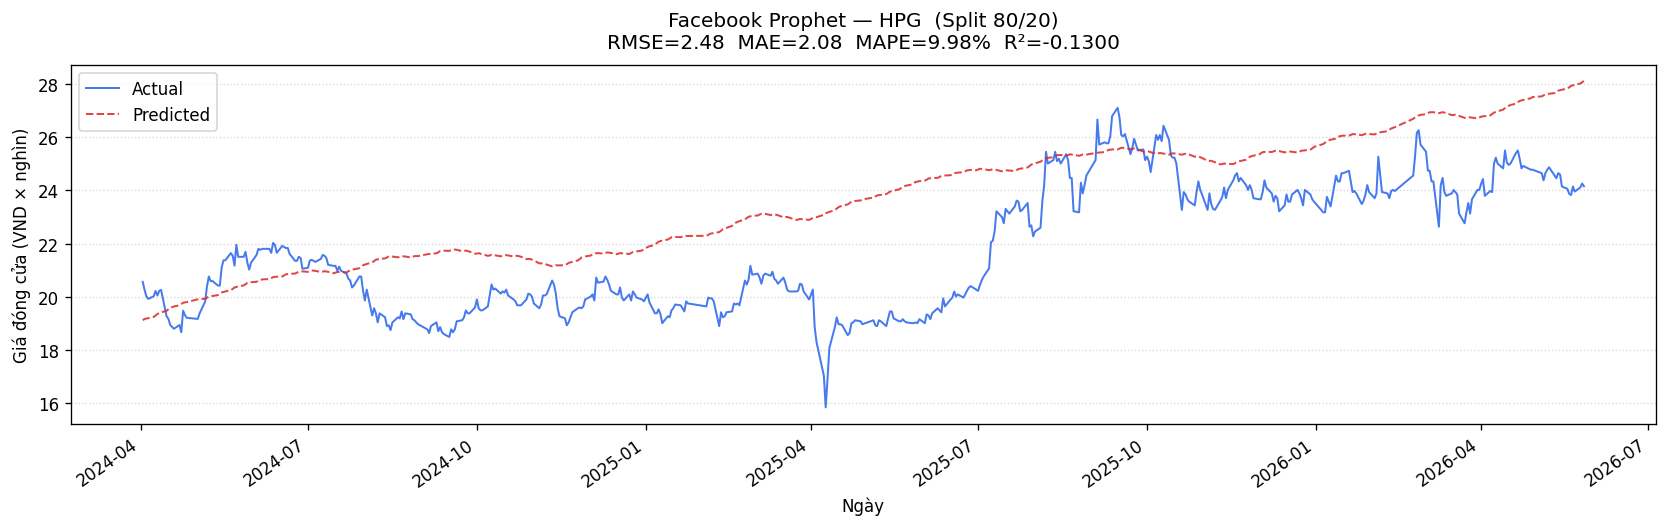


  > VIC...


22:22:07 - cmdstanpy - INFO - Chain [1] start processing
22:22:08 - cmdstanpy - INFO - Chain [1] done processing


     RMSE=82.79  MAE=53.42  MAPE=53.98%  R2=-0.9419  DA=44.4%


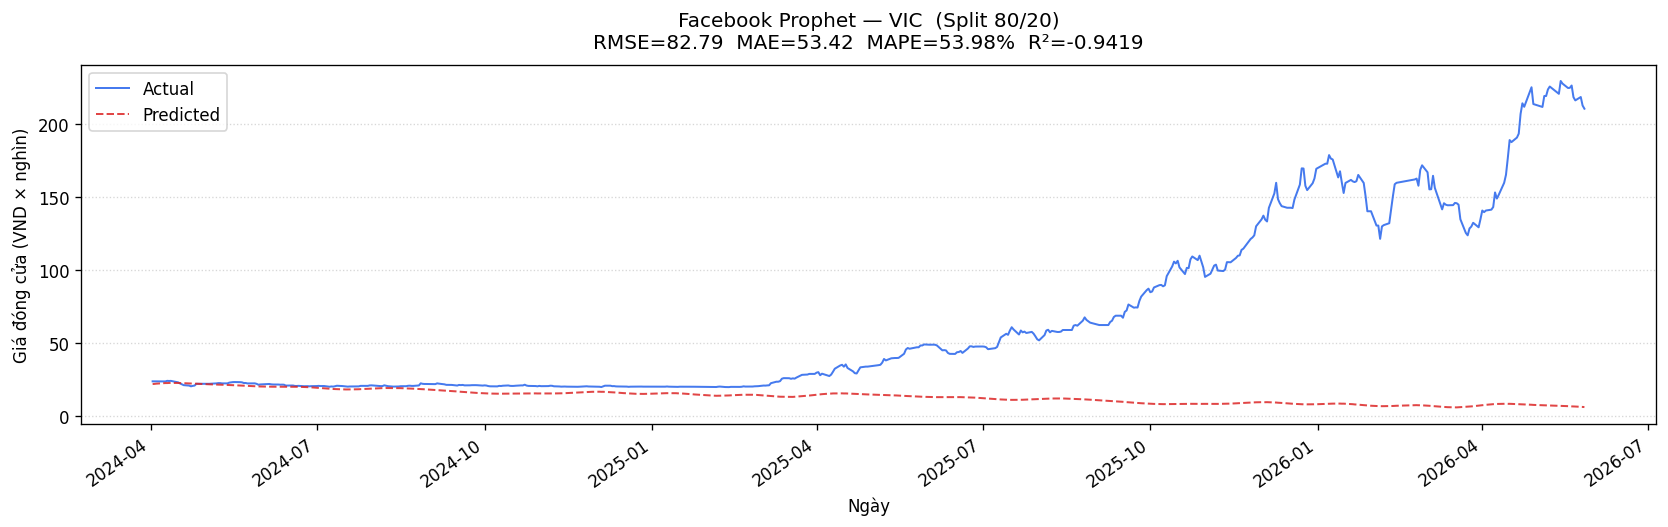


  > VNM...


22:22:08 - cmdstanpy - INFO - Chain [1] start processing
22:22:09 - cmdstanpy - INFO - Chain [1] done processing


     RMSE=3.83  MAE=3.07  MAPE=5.17%  R2=0.1196  DA=53.3%


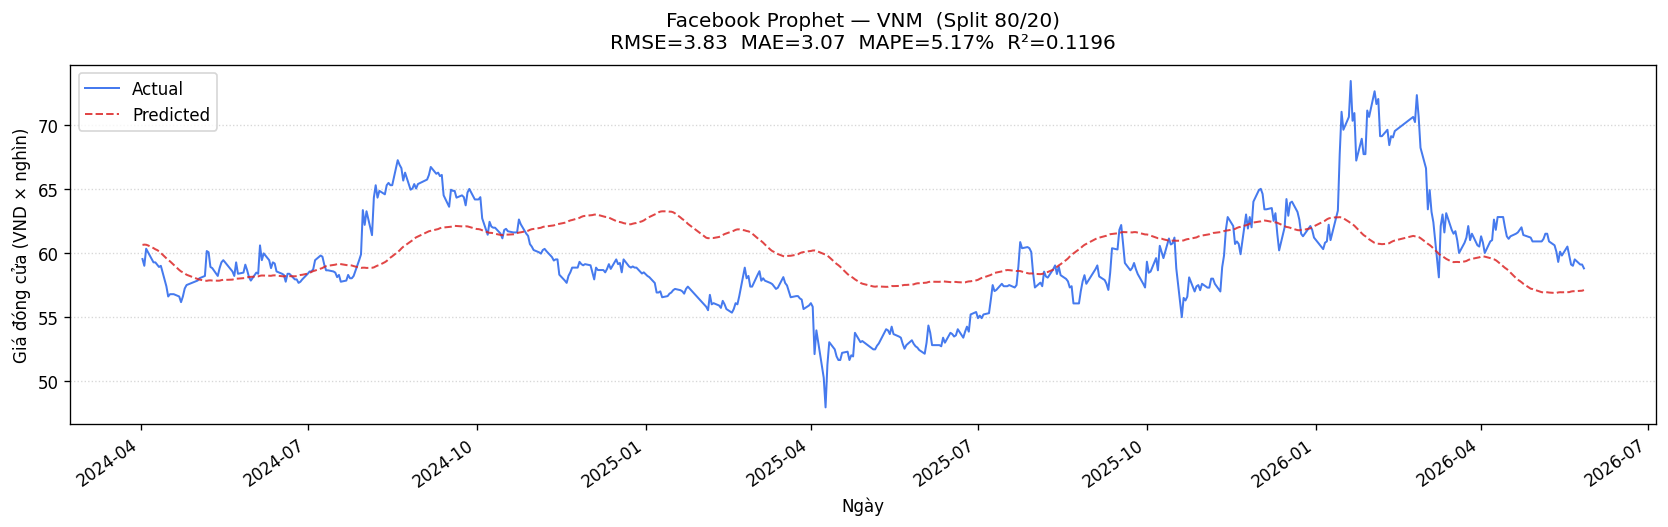

In [22]:
prediction_cache = {}
all_results = []

for split in SPLITS:
    print()
    print('=' * 55)
    print('  Split:', split.replace('_', '/'))
    print('=' * 55)

    for ticker in TICKERS:
        print()
        print('  > ', ticker, '...', sep='')
        train_df, test_df = load_split(ticker, split)

        y_pred = train_and_predict(train_df, test_df)
        y_true = test_df['close'].values.astype(float)
        prediction_cache[(ticker, split)] = y_pred

        prev_close = np.concatenate([[train_df['close'].iloc[-1]], y_true[:-1]])
        metrics = compute_metrics(y_true, y_pred, prev_close=prev_close)
        da = metrics.get('Directional Accuracy (%)', float('nan'))
        print(
            '     RMSE={:,.2f}  MAE={:,.2f}  MAPE={:.2f}%  R2={:.4f}  DA={:.1f}%'.format(
                metrics['RMSE'],
                metrics['MAE'],
                metrics['MAPE (%)'],
                metrics['R²'],
                da,
            )
        )

        plot_predictions(
            dates=test_df['date'],
            y_true=y_true,
            y_pred=y_pred,
            ticker=ticker,
            split=split,
            model_name=MODEL_NAME,
            metrics=metrics,
        )

        all_results.append({'Ticker': ticker, 'Split': split, 'Model': MODEL_NAME, **metrics})


---
## Section 5 — Bảng tổng hợp kết quả

In [23]:
results_df = build_results_table(all_results)

print()
print('─' * 75)
print('  Kết quả:', MODEL_NAME)
print('─' * 75)
print(results_df.to_string(index=False))

# Lưu CSV để thành viên 1 tổng hợp báo cáo
out_csv = RESULTS_DIR / f'{MODEL_NAME.lower().replace(" ", "_")}_results.csv'
results_df.to_csv(out_csv, index=False)
print()
print('  Đã lưu ->', out_csv)



───────────────────────────────────────────────────────────────────────────
  Kết quả: Facebook Prophet
───────────────────────────────────────────────────────────────────────────
Ticker Split            Model  RMSE   MAE  MAPE (%)       R²  Directional Accuracy (%)
   FPT 70_30 Facebook Prophet 43.09 37.27    37.492  -2.6927                     49.81
   HPG 70_30 Facebook Prophet 19.75 19.06    91.986 -42.0092                     50.81
   VCB 70_30 Facebook Prophet 13.62 13.17    21.852 -11.1293                     51.02
   VIC 70_30 Facebook Prophet 73.12 46.85    75.565  -0.9438                     47.13
   VNM 70_30 Facebook Prophet  9.03  7.42    12.095  -4.4229                     54.18
   FPT 80_20 Facebook Prophet 24.39 20.18    19.501  -2.0133                     48.18
   HPG 80_20 Facebook Prophet  2.48  2.08     9.976  -0.1300                     49.40
   VCB 80_20 Facebook Prophet 16.93 15.17    25.179 -25.3718                     48.65
   VIC 80_20 Facebook Prophet 82.79 

---
## Section 6 — Export to GitHub Pages Dashboard

Export predictions và metrics vào `docs/data/` để model xuất hiện trên dashboard của nhóm.  
**Không cần sửa** — chạy sau Section 5.

In [24]:
import json as _json

DOCS_DATA = ROOT / 'docs' / 'data'
DOCS_DATA.mkdir(parents=True, exist_ok=True)

_model_slug = MODEL_NAME.lower().replace(' ', '_')

pred_rows = []
for split in SPLITS:
    for ticker in TICKERS:
        train_df, test_df = load_split(ticker, split)
        y_pred = prediction_cache.get((ticker, split))
        if y_pred is None:
            y_pred = train_and_predict(train_df, test_df)
        y_true = test_df['close'].values.astype(float)

        for idx, row in test_df.reset_index(drop=True).iterrows():
            pred_rows.append({
                'date':      str(row['date'].date()),
                'actual':    round(float(y_true[idx]), 4),
                'predicted': round(float(y_pred[idx]), 4),
                'ticker':    ticker,
                'split':     split,
                'model':     MODEL_NAME,
            })

pred_df = pd.DataFrame(pred_rows)
pred_path = DOCS_DATA / f'{_model_slug}_predictions.csv'
pred_df.to_csv(pred_path, index=False)
print(f'Predictions -> {pred_path.relative_to(ROOT)}  ({len(pred_df)} rows)')

met_path = DOCS_DATA / f'{_model_slug}_metrics.csv'
results_df.to_csv(met_path, index=False)
print(f'Metrics     -> {met_path.relative_to(ROOT)}')

manifest_path = DOCS_DATA / 'manifest.json'
if manifest_path.exists():
    manifest = _json.loads(manifest_path.read_text())
else:
    manifest = {'models': [], 'last_updated': ''}

manifest['models'] = [m for m in manifest.get('models', []) if m['name'] != MODEL_NAME]
manifest['models'].append({
    'name':        MODEL_NAME,
    'predictions': f'data/{_model_slug}_predictions.csv',
    'metrics':     f'data/{_model_slug}_metrics.csv',
})
manifest['last_updated'] = pd.Timestamp.now().strftime('%Y-%m-%d')
manifest_path.write_text(_json.dumps(manifest, indent=2, ensure_ascii=False))
print(f'Manifest    -> {manifest_path.relative_to(ROOT)}  ({len(manifest["models"])} model(s))')


Predictions -> docs/data/facebook_prophet_predictions.csv  (6670 rows)
Metrics     -> docs/data/facebook_prophet_metrics.csv
Manifest    -> docs/data/manifest.json  (3 model(s))


---
## Ghi chú khi viết báo cáo

- **RMSE** (Root Mean Squared Error): đơn vị VND × nghìn — nhạy với outliers
- **MAE** (Mean Absolute Error): đơn vị VND × nghìn — giải thích trực quan hơn
- **MAPE** (%): sai số phần trăm — dùng để so sánh giữa các mã khác nhau mức giá
- **R²**: hệ số xác định — càng gần 1 càng tốt
- **Directional Accuracy** (%): % lần model dự đoán đúng hướng (tăng/giảm) so với ngày liền trước. Random ≈ 50%; > 55% là có skill về hướng. Quan trọng vì RMSE thấp không nhất thiết kéo theo dự đoán hướng tốt.

Khi viết báo cáo Chương 5, dùng cả 5 chỉ số. Mọi bảng phải thống nhất đơn vị.
Biểu đồ được lưu tại `results/<model_name>/plots/`.
